Install and Import Dependencies

In [1]:
%pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 --index-url https://download.pytorch.org/whl/cpu


Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download.pytorch.org/whl/cpu/torch-2.3.0%2Bcpu-cp311-cp311-win_amd64.whl (161.8 MB)
  Using cached https://download.pytorch.org/whl/cpu/torchvision-0.18.0%2Bcpu-cp311-cp311-win_amd64.whl (1.2 MB)
  Using cached https://download.pytorch.org/whl/cpu/torchaudio-2.3.0%2Bcpu-cp311-cp311-win_amd64.whl (2.4 MB)
     ---------------------------------------- 0.0/6.2 MB ? eta -:--:--
     ------ --------------------------------- 1.0/6.2 MB 8.4 MB/s eta 0:00:01
     ---------------------------------------- 6.2/6.2 MB 21.1 MB/s eta 0:00:00
     ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
     ---------------------------------------- 1.6/1.6 MB 44.7 MB/s eta 0:00:00
     ---------------------------------------- 0.0/228.5 MB ? eta -:--:--
      -------------------------------------- 3.7/228.5 MB 18.1 MB/s eta 0:00:13
     - ------------------------------------- 8.4/228.5 MB 20.8 MB/s eta 0:00:11
   

In [2]:
!git clone https://github.com/ultralytics/yolov5


Cloning into 'yolov5'...


In [3]:
%pip install gitpython matplotlib numpy opencv-python pillow psutil PyYAML requests scipy thop tqdm ultralytics setuptools pandas seaborn

  Using cached GitPython-3.1.43-py3-none-any.whl.metadata (13 kB)
  Using cached matplotlib-3.9.2-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached opencv_python-4.10.0.84-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached PyYAML-6.0.2-cp311-cp311-win_amd64.whl.metadata (2.1 kB)
  Using cached requests-2.32.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached scipy-1.14.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached thop-0.1.1.post2209072238-py3-none-any.whl.metadata (2.7 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached gitdb-4.0.11-py3-none-any.whl.metadata (1.2 kB)
  Using cached contourpy-1.3.0-cp311-cp311-win_amd64.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.54.1-cp311-cp311-win_amd64.whl.metadata (167 kB)
  Using cached kiwisolver-1.4.7-cp311-cp311-win_amd64.whl.metadata (6.4 kB)
  Using cached idna-3.10-py3-none-any.whl.metadata (10 kB)
  Using cached u

In [4]:
import torch
from matplotlib import pyplot as plt
import numpy as np
import cv2

Load Model

In [5]:
model = torch.hub.load('ultralytics/yolov5', 'yolov5s')

Using cache found in C:\Users\akash/.cache\torch\hub\ultralytics_yolov5_master


Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\akash\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
requirements: Ultralytics requirements ['pillow>=10.3.0', 'setuptools>=70.0.0'] not found, attempting AutoUpdate...
   ---------------------------------------- 2.6/2.6 MB 3.5 MB/s eta 0:00:00
   ---------------------------------------- 1.3/1.3 MB 4.9 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 65.5.0
    Uninstalling setuptools-65.5.0:
      Successfully uninstalled setuptools-65.5.0
  Attempting uninstall: pillow
    Found existing installation: pillow 10.2.0
    Uninstalling pillow-10.2.0:
      Successfully uninstalled pillow-10.2.0

requirements: AutoUpdate success  8.6s, installed 2 packages: ['pillow>=10.3.0

YOLOv5  2024-11-5 Python-3.11.2 torch-2.3.0+cpu CPU

100%|██████████| 14.1M/14.1M [00:00<00:00, 21.5MB/s]

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


In [6]:
model

AutoShape(
  (model): DetectMultiBackend(
    (model): DetectionModel(
      (model): Sequential(
        (0): Conv(
          (conv): Conv2d(3, 32, kernel_size=(6, 6), stride=(2, 2), padding=(2, 2))
          (act): SiLU(inplace=True)
        )
        (1): Conv(
          (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (act): SiLU(inplace=True)
        )
        (2): C3(
          (cv1): Conv(
            (conv): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
            (act): SiLU(inplace=True)
          )
          (cv2): Conv(
            (conv): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
            (act): SiLU(inplace=True)
          )
          (cv3): Conv(
            (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
            (act): SiLU(inplace=True)
          )
          (m): Sequential(
            (0): Bottleneck(
              (cv1): Conv(
                (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
  

Make Detection with images

In [7]:
img = 'https://upload.wikimedia.org/wikipedia/commons/thumb/e/e4/Cars_in_traffic_in_Auckland%2C_New_Zealand_-_copyright-free_photo_released_to_public_domain.jpg/1200px-Cars_in_traffic_in_Auckland%2C_New_Zealand_-_copyright-free_photo_released_to_public_domain.jpg?20190503075536'

In [8]:
results = model(img)
results.print()

image 1/1: 800x1200 1 person, 31 cars, 4 trucks
Speed: 728.2ms pre-process, 147.9ms inference, 1.0ms NMS per image at shape (1, 3, 448, 640)


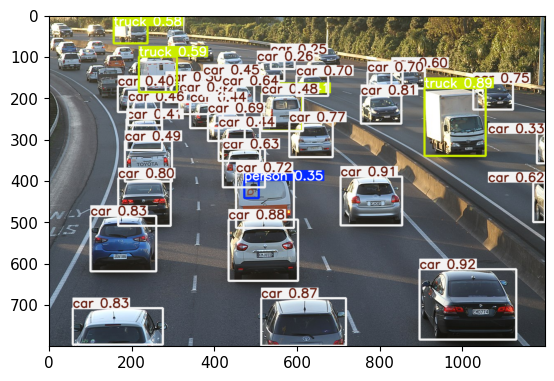

In [9]:
%matplotlib inline 
plt.imshow(np.squeeze(results.render()))
plt.show()

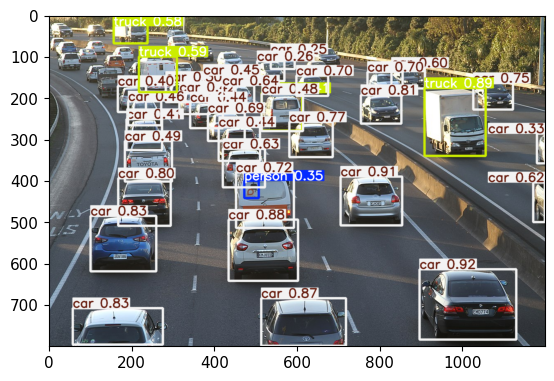

In [10]:
plt.imshow(np.squeeze(results.render()))

Real Time Detections

In [14]:
cap = cv2.VideoCapture(0)
while cap.isOpened():
    ret, frame = cap.read()
    
    # Make detections 
    results = model(frame)
    
    cv2.imshow('YOLO', np.squeeze(results.render()))
    
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

Train from scratch

In [15]:
import uuid   # Unique identifier
import os
import time

In [16]:
IMAGES_PATH = os.path.join('data', 'images') #/data/images
labels = ['awake', 'drowsy']
number_imgs = 10

In [15]:

cap = cv2.VideoCapture(0)
# Loop through labels
for label in labels:
    print('Collecting images for {}'.format(label))
    time.sleep(5)
    
    # Loop through image range
    for img_num in range(number_imgs):
        print('Collecting images for {}, image number {}'.format(label, img_num))
        
        # Webcam feed
        ret, frame = cap.read()
        
        # Naming out image path
        imgname = os.path.join(IMAGES_PATH, label+'.'+str(uuid.uuid1())+'.jpg')
        
        # Writes out image to file 
        cv2.imwrite(imgname, frame)
        
        # Render to the screen
        cv2.imshow('Image Collection', frame)
        
        # 2 second delay between captures
        time.sleep(2)
        
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
cap.release()
cv2.destroyAllWindows()

In [17]:
print(os.path.join(IMAGES_PATH, labels[0]+'.'+str(uuid.uuid1())+'.jpg'))


data\images\awake.828ce3a4-9b67-11ef-bc80-845cf33627dd.jpg


In [18]:

for label in labels:
    print('Collecting images for {}'.format(label))
    for img_num in range(number_imgs):
        print('Collecting images for {}, image number {}'.format(label, img_num))
        imgname = os.path.join(IMAGES_PATH, label+'.'+str(uuid.uuid1())+'.jpg')
        print(imgname)  

data\images\awake.8710ad5f-9b67-11ef-8d85-845cf33627dd.jpg
data\images\awake.8710ad60-9b67-11ef-ab26-845cf33627dd.jpg
data\images\awake.8710ad61-9b67-11ef-9f2d-845cf33627dd.jpg
data\images\awake.8710ad62-9b67-11ef-8f66-845cf33627dd.jpg
data\images\awake.8710ad63-9b67-11ef-bc3e-845cf33627dd.jpg
data\images\awake.8710ad64-9b67-11ef-ae19-845cf33627dd.jpg
data\images\awake.8710ad65-9b67-11ef-809e-845cf33627dd.jpg
data\images\awake.8710ad66-9b67-11ef-b2ed-845cf33627dd.jpg
data\images\awake.8710ad67-9b67-11ef-8dbb-845cf33627dd.jpg
data\images\awake.8710ad68-9b67-11ef-a601-845cf33627dd.jpg
data\images\drowsy.8710ad69-9b67-11ef-aead-845cf33627dd.jpg
data\images\drowsy.8710d46f-9b67-11ef-82d6-845cf33627dd.jpg
data\images\drowsy.8710d470-9b67-11ef-82fb-845cf33627dd.jpg
data\images\drowsy.8710d471-9b67-11ef-85d4-845cf33627dd.jpg
data\images\drowsy.8710d472-9b67-11ef-8428-845cf33627dd.jpg
data\images\drowsy.8710d473-9b67-11ef-afc2-845cf33627dd.jpg
data\images\drowsy.8710d474-9b67-11ef-b3b6-845cf33

In [19]:
!git clone https://github.com/tzutalin/labelImg


fatal: destination path 'labelImg' already exists and is not an empty directory.


In [20]:

%pip install pyqt5 lxml --upgrade
%cd labelImg && pyrcc5 -o libs/resources.py resources.qrc

  Using cached PyQt5-5.15.11-cp38-abi3-win_amd64.whl.metadata (2.1 kB)
  Using cached lxml-5.3.0-cp311-cp311-win_amd64.whl.metadata (3.9 kB)
  Using cached PyQt5_sip-12.15.0-cp311-cp311-win_amd64.whl.metadata (439 bytes)
  Using cached PyQt5_Qt5-5.15.2-py3-none-win_amd64.whl.metadata (552 bytes)
Using cached PyQt5-5.15.11-cp38-abi3-win_amd64.whl (6.9 MB)
Using cached lxml-5.3.0-cp311-cp311-win_amd64.whl (3.8 MB)
Using cached PyQt5_Qt5-5.15.2-py3-none-win_amd64.whl (50.1 MB)
Using cached PyQt5_sip-12.15.0-cp311-cp311-win_amd64.whl (59 kB)
Note: you may need to restart the kernel to use updated packages.
[WinError 3] The system cannot find the path specified: 'labelImg && pyrcc5 -o libs/resources.py resources.qrc'
c:\Users\akash\Dropbox\My PC (LAPTOP-L3H5JIVT)\Desktop\DrowzGaurd


In [50]:
!cd yolov5 && python train.py --img 320 --batch 5 --epochs 500 --data dataset.yml --weights yolov5s.pt --workers 2


train: weights=yolov5s.pt, cfg=, data=dataset.yml, hyp=data\hyps\hyp.scratch-low.yaml, epochs=500, batch_size=5, imgsz=320, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data\hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=2, project=runs\train, name=exp, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, seed=0, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1, artifact_alias=latest, ndjson_console=False, ndjson_file=False
github: up to date with https://github.com/ultralytics/yolov5 
fatal: cannot change to 'C:\Users\akash\Dropbox\My': No such file or directory
YOLOv5  2024-11-5 Python-3.11.2 torch-2.3.0+cpu CPU

hyperparameters: lr0=0.01, lrf=0.01, momentum=0.937, weight_decay=0.0005, warmup_epochs=3.0, warmup_momentum=0.8, warmup_bias_lr

Load Custom Model

In [57]:
model = torch.hub.load('ultralytics/yolov5', 'custom', path='yolov5/runs/train/exp2/weights/last.pt', force_reload=True)

Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to C:\Users\akash/.cache\torch\hub\master.zip
YOLOv5  2024-11-5 Python-3.11.2 torch-2.3.0+cpu CPU

Fusing layers... 
Model summary: 157 layers, 7055974 parameters, 0 gradients, 15.9 GFLOPs
Adding AutoShape... 


In [58]:
img = os.path.join('data', 'images', 'drowsy.31d11e16-62d6-11ef-9335-bae89a6c897c.jpg')

In [59]:
results = model(img)

In [60]:
results.print()

image 1/1: 480x640 (no detections)
Speed: 5.3ms pre-process, 107.6ms inference, 0.0ms NMS per image at shape (1, 3, 480, 640)


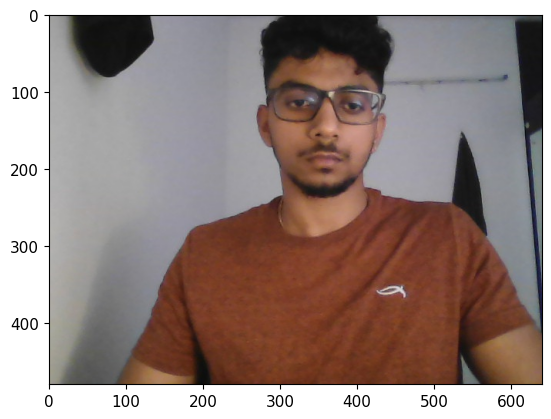

In [61]:
%matplotlib inline 
plt.imshow(np.squeeze(results.render()))
plt.show()

In [62]:
cap = cv2.VideoCapture(0)
while cap.isOpened():
    ret, frame = cap.read()
    
    # Make detections 
    results = model(frame)
    
    cv2.imshow('YOLO', np.squeeze(results.render()))
    
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()